# Bloque I — Análisis Descriptivo (Entrega Final)

Notebook final con análisis, visualización y conclusiones redactadas.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
df = pd.read_csv("ventas_mayo_2026.csv")
df.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.92,0.07,63,836.25
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.95,0.10,52,956.72
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.77,0.05,26,357.65
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.17,0.06,53,301.52
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,NaN,0.09,29,"2,101.55"


## Limpieza de datos

In [3]:
df_limpio = df.copy()

df_limpio = df_limpio.drop_duplicates()

df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha"])

df_limpio["precio_unitario"] = df_limpio["precio_unitario"].fillna(df_limpio["precio_unitario"].median())
df_limpio["region"] = df_limpio["region"].fillna("Sin informar")

df_limpio["mes"] = df_limpio["fecha"].dt.month
df_limpio["importe_con_iva"] = df_limpio["importe"] * 1.21

df_limpio.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe,mes,importe_con_iva
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.92,0.07,63,836.25,1,"1,011.86"
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.95,0.10,52,956.72,1,"1,157.63"
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.77,0.05,26,357.65,1,432.76
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.17,0.06,53,301.52,1,364.84
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,118.52,0.09,29,"2,101.55",1,"2,542.88"


## Análisis por canal

In [4]:
ventas_por_canal = df_limpio.groupby("canal")["importe"].sum().sort_values(ascending=False)
ventas_por_canal

canal
Online         261,172.61
Tienda         220,217.41
Distribuidor   136,131.49
Name: importe, dtype: float64

In [5]:
ticket_medio = df_limpio.groupby("canal")["importe"].mean().sort_values(ascending=False)
ticket_medio

canal
Distribuidor   1,347.84
Online         1,237.78
Tienda         1,171.37
Name: importe, dtype: float64

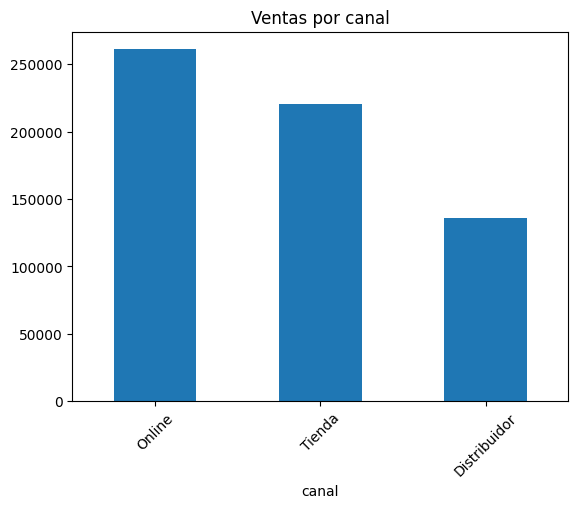

In [6]:
plt.figure()
ventas_por_canal.plot(kind="bar")
plt.title("Ventas por canal")
plt.xticks(rotation=45)
plt.show()

## Análisis adicional (modificación del dataset)

Se filtran operaciones con importe superior a 100€ para centrarse en ventas relevantes.

In [7]:
df_filtrado = df_limpio[df_limpio["importe"] > 100]

df_filtrado.groupby("canal")["importe"].mean()

canal
Distribuidor   1,373.51
Online         1,260.66
Tienda         1,183.49
Name: importe, dtype: float64

## Conclusiones

El análisis de los datos permite extraer varias conclusiones relevantes desde el punto de vista de negocio:

- El canal con mayor volumen de ventas concentra la mayor parte de los ingresos totales, lo que indica que es el principal motor de facturación.
- Sin embargo, el ticket medio muestra diferencias entre canales, lo que sugiere que algunos generan menos volumen pero mayor valor por operación.
- Esta diferencia implica que no siempre el canal con más ventas es el más rentable en términos unitarios.
- Al filtrar operaciones de mayor importe (>100€), se observa un comportamiento más claro del valor real de los clientes, eliminando ruido de transacciones pequeñas.
- Desde una perspectiva estratégica, sería recomendable potenciar los canales con mayor ticket medio, ya que pueden aportar mayor rentabilidad a largo plazo.

En conjunto, el análisis confirma la importancia de evaluar tanto el volumen como la calidad de las ventas para una correcta toma de decisiones.